# DINO Feature Injection into ControlNet — Prototype
**Goal:** Extract DINO features from an edited panda image (view 0), inject them into the ControlNet denoising loop for a different view, and compare with/without injection.

## Cell 1: Imports

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from diffusers.schedulers import DDIMScheduler, DDIMInverseScheduler
from diffusers.models.attention_processor import AttnProcessor
from transformers import AutoModel, AutoImageProcessor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16
print(f"Using device: {device}")

Using device: cuda


## Cell 2: Load Stable Diffusion + ControlNet (same as GaussCtrl)

In [2]:
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-depth", torch_dtype=dtype
)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=dtype,
).to(device)

# Extract individual components for manual denoising loop
unet = pipe.unet
controlnet = pipe.controlnet
vae = pipe.vae
text_encoder = pipe.text_encoder
tokenizer = pipe.tokenizer
scheduler = DDIMScheduler.from_pretrained(
    "runwayml/stable-diffusion-v1-5", subfolder="scheduler"
)

print("Models loaded.")

/data/leuven/385/vsc38511/miniconda3/envs/gaussctrl_v100/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/data/leuven/385/vsc38511/miniconda3/envs/gaussctrl_v100/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Models loaded.


## Cell 3: Load DINO model

In [3]:
dino_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
dino_model = AutoModel.from_pretrained("facebook/dinov2-small").to(device).eval()

print(f"DINO model loaded.")
print(f"  Patch size: {dino_model.config.patch_size}")
print(f"  Hidden size: {dino_model.config.hidden_size}")

DINO model loaded.
  Patch size: 14
  Hidden size: 384


## Cell 4: Load your images
**Fill in the paths below with your actual files.**

Depth shape: (1, 512, 512), range: [0.6719, 4.6836]


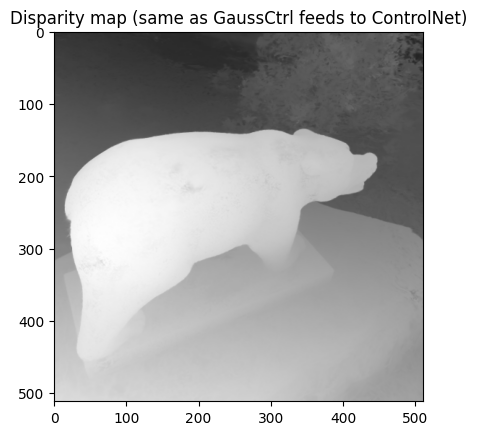

Edited panda size: (512, 512)
Unedited bear size: (512, 512)
Depth map size: (512, 512)


In [7]:
# ============================================================
# YOU FILL THESE IN with your actual image paths
# ============================================================

edited_panda_image = Image.open("/data/leuven/385/vsc38511/outputs/debug_edited_images/panda_seq_v4/ref_00_idx0004_edited.png").convert("RGB")
unedited_bear_image = Image.open("/data/leuven/385/vsc38511/outputs/debug_edited_images/panda_seq_v4/ref_01_idx0011_unedited.png").convert("RGB")




depth_npy = np.load("/data/leuven/385/vsc38511/outputs/cache/bear/0011_depth.npy")  # check the shape first
print(f"Depth shape: {depth_npy.shape}, range: [{depth_npy.min():.4f}, {depth_npy.max():.4f}]")

# Convert to disparity (same as GaussCtrl's depth2disparity)
disparity = 1 / (depth_npy + 1e-5)
disparity_map = disparity / np.max(disparity)

# Make sure it's [H, W, 3]
if disparity_map.ndim == 2:
    disparity_map = disparity_map[:, :, None]
if disparity_map.shape[0] == 1:  # [1, 512, 512] -> [512, 512, 1]
    disparity_map = disparity_map.transpose(1, 2, 0)
disparity_rgb = np.concatenate([disparity_map] * 3, axis=2)

depth_map_image = Image.fromarray((disparity_rgb * 255).astype(np.uint8))

plt.imshow(depth_map_image)
plt.title("Disparity map (same as GaussCtrl feeds to ControlNet)")
plt.show()
print(f"Edited panda size: {edited_panda_image.size}")
print(f"Unedited bear size: {unedited_bear_image.size}")
print(f"Depth map size: {depth_map_image.size}")

## Cell 5: Extract DINO features from the edited panda

In [8]:
def extract_dino_features(image_pil, model, processor, target_device):
    """
    Extract patch-level DINO features from an image.
    Returns: (1, hidden_dim, H_patches, W_patches) tensor
    """
    inputs = processor(images=image_pil, return_tensors="pt").to(target_device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # last_hidden_state: (1, 1 + num_patches, hidden_dim)
    # Position 0 is the CLS token - remove it
    patch_tokens = outputs.last_hidden_state[:, 1:, :]
    
    num_patches = patch_tokens.shape[1]
    h = w = int(num_patches ** 0.5)
    assert h * w == num_patches, f"Non-square patch grid: {num_patches} patches"
    
    hidden_dim = patch_tokens.shape[2]
    feat_map = patch_tokens.reshape(1, h, w, hidden_dim).permute(0, 3, 1, 2)
    
    return feat_map

dino_features = extract_dino_features(edited_panda_image, dino_model, dino_processor, device)
print(f"DINO feature map shape: {dino_features.shape}")

DINO feature map shape: torch.Size([1, 384, 16, 16])


## Cell 6: Visualize DINO features (sanity check)

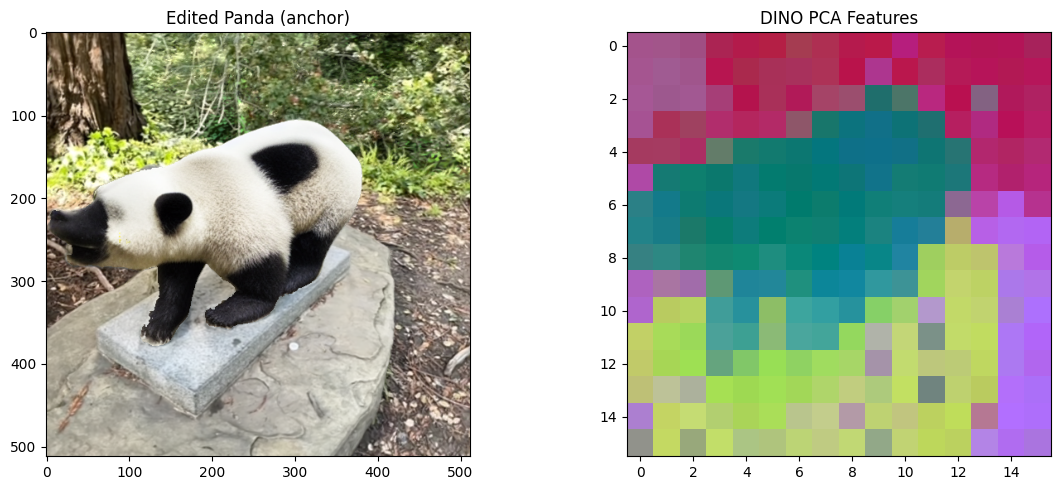

In [9]:
feat_np = dino_features.squeeze(0).permute(1, 2, 0).cpu().numpy()
h, w, c = feat_np.shape
feat_flat = feat_np.reshape(-1, c)

pca = PCA(n_components=3)
pca_result = pca.fit_transform(feat_flat).reshape(h, w, 3)
pca_result = (pca_result - pca_result.min()) / (pca_result.max() - pca_result.min())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(edited_panda_image)
axes[0].set_title("Edited Panda (anchor)")
axes[1].imshow(pca_result)
axes[1].set_title("DINO PCA Features")
plt.tight_layout()
plt.show()

## Cell 7: DINO Projection Layer
Projects DINO features (384 channels) to match ControlNet residual dimensions (320 channels at 64x64).

In [10]:
class DinoProjector(torch.nn.Module):
    """Projects DINO features to match ControlNet residual dimensions."""
    def __init__(self, dino_dim=384, target_channels=320):
        super().__init__()
        self.proj = torch.nn.Conv2d(dino_dim, target_channels, kernel_size=1, bias=False)
        torch.nn.init.normal_(self.proj.weight, std=0.02)
    
    def forward(self, dino_feat_map, target_h, target_w):
        x = F.interpolate(dino_feat_map, size=(target_h, target_w),
                          mode='bilinear', align_corners=False)
        x = self.proj(x)
        return x

projector_64 = DinoProjector(dino_dim=384, target_channels=320).to(device).to(dtype)
print("Projector created: DINO 384 -> ControlNet 320 channels")

Projector created: DINO 384 -> ControlNet 320 channels


## Cell 8: Helper functions

In [11]:
def encode_prompt(prompt, negative_prompt=""):
    """Encode text prompt to embeddings for classifier-free guidance."""
    text_input = tokenizer(
        prompt, padding="max_length", max_length=tokenizer.model_max_length,
        truncation=True, return_tensors="pt"
    ).to(device)
    prompt_embeds = text_encoder(text_input.input_ids)[0]
    
    uncond_input = tokenizer(
        negative_prompt, padding="max_length", max_length=tokenizer.model_max_length,
        truncation=True, return_tensors="pt"
    ).to(device)
    uncond_embeds = text_encoder(uncond_input.input_ids)[0]
    
    return torch.cat([uncond_embeds, prompt_embeds])

def image_to_latent(image_pil):
    """Encode a PIL image to VAE latent space."""
    image_np = np.array(image_pil).astype(np.float32) / 255.0
    image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).unsqueeze(0)
    image_tensor = (image_tensor * 2.0 - 1.0).to(device).to(dtype)
    with torch.no_grad():
        latent = vae.encode(image_tensor).latent_dist.sample() * vae.config.scaling_factor
    return latent

def latent_to_image(latent):
    """Decode a VAE latent to PIL image."""
    with torch.no_grad():
        image = vae.decode(latent / vae.config.scaling_factor).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    image = image.cpu().permute(0, 2, 3, 1).numpy()[0]
    return Image.fromarray((image * 255).astype(np.uint8))

def prepare_depth_conditioning(depth_image_pil):
    """Convert depth image to ControlNet input format."""
    depth_np = np.array(depth_image_pil.resize((512, 512))).astype(np.float32)
    if depth_np.ndim == 3:
        depth_np = depth_np[:, :, 0]
    depth_np = (depth_np - depth_np.min()) / (depth_np.max() - depth_np.min() + 1e-8)
    depth_tensor = torch.from_numpy(depth_np).unsqueeze(0).unsqueeze(0)
    depth_tensor = depth_tensor.repeat(1, 3, 1, 1)
    return depth_tensor.to(device).to(dtype)

print("Helper functions defined.")

Helper functions defined.


## Cell 9: DDIM Inversion

In [12]:
@torch.no_grad()
def ddim_invert(latent, prompt_embeds, depth_cond, num_steps=50):
    """DDIM inversion: encode z0 -> zT (noise), conditioned on depth."""
    scheduler.set_timesteps(num_steps)
    timesteps = reversed(scheduler.timesteps)
    
    z = latent.clone()
    
    for t in timesteps:
        t_tensor = torch.tensor([t], device=device)
        
        down_res, mid_res = controlnet(
            z, t_tensor,
            encoder_hidden_states=prompt_embeds[1:],
            controlnet_cond=depth_cond,
            return_dict=False,
        )
        
        noise_pred = unet(
            z, t_tensor,
            encoder_hidden_states=prompt_embeds[1:],
            down_block_additional_residuals=down_res,
            mid_block_additional_residual=mid_res,
        ).sample
        
        alpha_t = scheduler.alphas_cumprod[t]
        alpha_next = scheduler.alphas_cumprod[
            min(t + scheduler.config.num_train_timesteps // num_steps,
                scheduler.config.num_train_timesteps - 1)
        ]
        
        z = (z - (1 - alpha_t).sqrt() * noise_pred) / alpha_t.sqrt()
        z = alpha_next.sqrt() * z + (1 - alpha_next).sqrt() * noise_pred
    
    return z

print("DDIM inversion function defined.")

DDIM inversion function defined.


## Cell 10: Main denoising loop with DINO injection
This is the core of the experiment. At each denoising step:
1. Run ControlNet on the depth map -> get residuals
2. **Add** projected DINO features to the 64x64 residuals
3. Run UNet with the modified residuals

In [13]:
@torch.no_grad()
def denoise_with_dino_injection(
    z_T,
    prompt_embeds,
    depth_cond,
    dino_feat_map,
    projector,
    num_steps=50,
    guidance_scale=7.5,
    dino_injection_scale=0.3,
    inject_at_indices=None,
):
    """
    Manual denoising loop with DINO feature injection.
    
    Args:
        z_T: starting noise from DDIM inversion
        prompt_embeds: (2, 77, 768) stacked [uncond, cond]
        depth_cond: (1, 3, 512, 512) depth map
        dino_feat_map: (1, 384, H, W) DINO features from anchor image
        projector: DinoProjector module
        dino_injection_scale: lambda - strength of DINO signal
        inject_at_indices: which ControlNet residual indices to inject at
    """
    scheduler.set_timesteps(num_steps)
    z = z_T.clone()
    
    if inject_at_indices is None:
        inject_at_indices = [0, 1, 2]  # 64x64 residuals (320 channels)
    
    for i, t in enumerate(scheduler.timesteps):
        z_input = torch.cat([z] * 2)
        t_tensor = torch.tensor([t], device=device)
        depth_input = torch.cat([depth_cond] * 2)
        
        # Step A: ControlNet forward
        down_block_res_samples, mid_block_res_sample = controlnet(
            z_input, t_tensor,
            encoder_hidden_states=prompt_embeds,
            controlnet_cond=depth_input,
            return_dict=False,
        )
        
        # Step B: Inject DINO features into residuals
        down_block_res_samples = list(down_block_res_samples)
        
        if dino_feat_map is not None and dino_injection_scale > 0:
            for idx in inject_at_indices:
                res = down_block_res_samples[idx]
                _, C, H, W = res.shape
                
                dino_projected = projector(dino_feat_map, H, W)
                dino_projected = torch.cat([dino_projected] * 2)  # expand for CFG
                
                down_block_res_samples[idx] = res + dino_injection_scale * dino_projected
        
        down_block_res_samples = tuple(down_block_res_samples)
        
        # Step C: UNet forward with modified residuals
        noise_pred = unet(
            z_input, t_tensor,
            encoder_hidden_states=prompt_embeds,
            down_block_additional_residuals=down_block_res_samples,
            mid_block_additional_residual=mid_block_res_sample,
        ).sample
        
        # Step D: Classifier-free guidance
        noise_pred_uncond, noise_pred_cond = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)
        
        # Step E: DDIM step
        z = scheduler.step(noise_pred, t, z).prev_sample
    
    return z

print("Denoising function with DINO injection defined.")

Denoising function with DINO injection defined.


## Cell 11: Prepare inputs and run DDIM inversion

In [14]:
edit_prompt = "a photo of a panda in the forest"
negative_prompt = "longbody, lowres, bad anatomy, bad hands, missing fingers"
prompt_embeds = encode_prompt(edit_prompt, negative_prompt)
print(f"Prompt embeddings: {prompt_embeds.shape}")

depth_cond = prepare_depth_conditioning(depth_map_image)
print(f"Depth conditioning: {depth_cond.shape}")

dino_features_fp16 = dino_features.to(dtype)
print(f"DINO features: {dino_features_fp16.shape}")

# DDIM inversion of the unedited bear view
print("\nRunning DDIM inversion...")
z_0 = image_to_latent(unedited_bear_image.resize((512, 512)))

reverse_prompt = "a photo of a bear in the forest"
reverse_embeds = encode_prompt(reverse_prompt, "")
z_T = ddim_invert(z_0, reverse_embeds, depth_cond, num_steps=50)
print(f"DDIM inversion done. z_T shape: {z_T.shape}")

Prompt embeddings: torch.Size([2, 77, 768])
Depth conditioning: torch.Size([1, 3, 512, 512])
DINO features: torch.Size([1, 384, 16, 16])

Running DDIM inversion...
DDIM inversion done. z_T shape: torch.Size([1, 4, 64, 64])


## Cell 12: Generate baseline (NO DINO injection)

Generating baseline (no DINO)...
Saved: result_baseline_no_dino.png


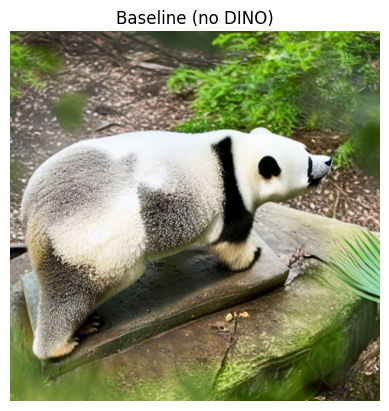

In [15]:
print("Generating baseline (no DINO)...")

z_edited_baseline = denoise_with_dino_injection(
    z_T=z_T,
    prompt_embeds=prompt_embeds,
    depth_cond=depth_cond,
    dino_feat_map=None,
    projector=projector_64,
    num_steps=50,
    guidance_scale=7.5,
    dino_injection_scale=0.0,
)

baseline_image = latent_to_image(z_edited_baseline)
baseline_image.save("result_baseline_no_dino.png")
print("Saved: result_baseline_no_dino.png")
plt.imshow(baseline_image)
plt.title("Baseline (no DINO)")
plt.axis("off")
plt.show()

## Cell 13: Generate with DINO injection at multiple strengths

In [16]:
injection_scales = [0.1, 0.3, 0.5, 1.0]
dino_results = {}

for lam in injection_scales:
    print(f"Running with lambda = {lam}...")
    z_edited = denoise_with_dino_injection(
        z_T=z_T,
        prompt_embeds=prompt_embeds,
        depth_cond=depth_cond,
        dino_feat_map=dino_features_fp16,
        projector=projector_64,
        num_steps=50,
        guidance_scale=7.5,
        dino_injection_scale=lam,
        inject_at_indices=[0, 1, 2],
    )
    result_image = latent_to_image(z_edited)
    result_image.save(f"result_dino_lambda_{lam}.png")
    dino_results[lam] = result_image
    print(f"  Saved: result_dino_lambda_{lam}.png")

Running with lambda = 0.1...
  Saved: result_dino_lambda_0.1.png
Running with lambda = 0.3...
  Saved: result_dino_lambda_0.3.png
Running with lambda = 0.5...
  Saved: result_dino_lambda_0.5.png
Running with lambda = 1.0...
  Saved: result_dino_lambda_1.0.png


## Cell 14: Compare all results side by side

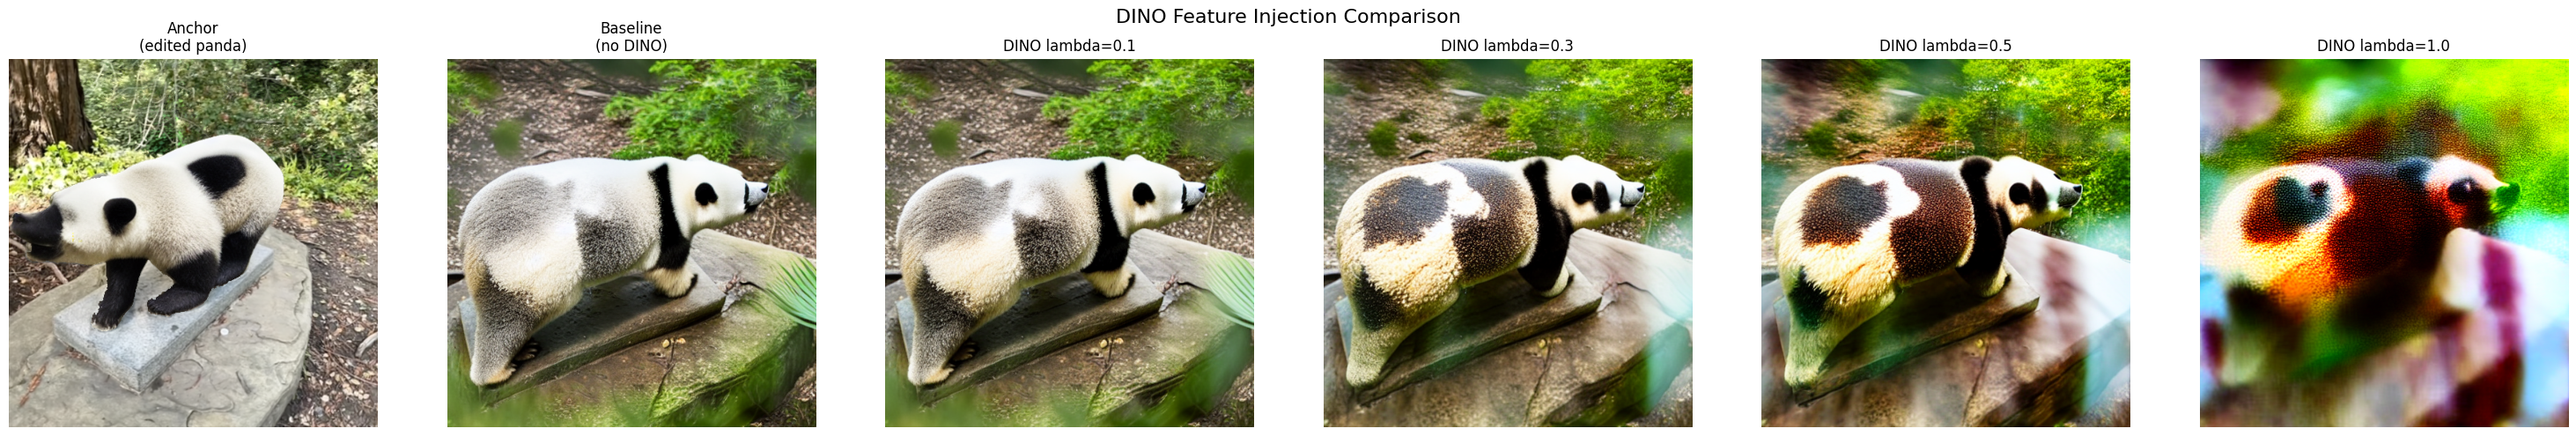

Saved: comparison_dino_injection.png


In [17]:
fig, axes = plt.subplots(1, 2 + len(injection_scales), 
                         figsize=(5 * (2 + len(injection_scales)), 5))

axes[0].imshow(edited_panda_image)
axes[0].set_title("Anchor\n(edited panda)")
axes[0].axis("off")

axes[1].imshow(baseline_image)
axes[1].set_title("Baseline\n(no DINO)")
axes[1].axis("off")

for i, lam in enumerate(injection_scales):
    axes[2 + i].imshow(dino_results[lam])
    axes[2 + i].set_title(f"DINO lambda={lam}")
    axes[2 + i].axis("off")

plt.suptitle("DINO Feature Injection Comparison", fontsize=16)
plt.tight_layout()
plt.savefig("comparison_dino_injection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparison_dino_injection.png")

## Cell 15: Reference - ControlNet residual shapes
Run this to see the exact dimensions of each ControlNet residual.

In [18]:
dummy_latent = torch.randn(1, 4, 64, 64, device=device, dtype=dtype)
dummy_t = torch.tensor([500], device=device)
dummy_prompt = prompt_embeds[1:]

down_res, mid_res = controlnet(
    dummy_latent, dummy_t,
    encoder_hidden_states=dummy_prompt,
    controlnet_cond=depth_cond,
    return_dict=False,
)

print("ControlNet residual shapes:")
print("-" * 40)
for i, r in enumerate(down_res):
    print(f"  down_block[{i:2d}]: {r.shape}")
print(f"  mid_block:     {mid_res.shape}")
print()
print("Indices [0,1,2]   -> 64x64, 320ch")
print("Indices [3,4,5]   -> 32x32, 640ch")
print("Indices [6,7,8]   -> 16x16, 1280ch")
print("Indices [9,10,11] -> 8x8, 1280ch")
print()
print("To inject at more scales, create additional projectors:")
print("  projector_32 = DinoProjector(384, 640).to(device).to(dtype)")
print("  projector_16 = DinoProjector(384, 1280).to(device).to(dtype)")

ControlNet residual shapes:
----------------------------------------
  down_block[ 0]: torch.Size([1, 320, 64, 64])
  down_block[ 1]: torch.Size([1, 320, 64, 64])
  down_block[ 2]: torch.Size([1, 320, 64, 64])
  down_block[ 3]: torch.Size([1, 320, 32, 32])
  down_block[ 4]: torch.Size([1, 640, 32, 32])
  down_block[ 5]: torch.Size([1, 640, 32, 32])
  down_block[ 6]: torch.Size([1, 640, 16, 16])
  down_block[ 7]: torch.Size([1, 1280, 16, 16])
  down_block[ 8]: torch.Size([1, 1280, 16, 16])
  down_block[ 9]: torch.Size([1, 1280, 8, 8])
  down_block[10]: torch.Size([1, 1280, 8, 8])
  down_block[11]: torch.Size([1, 1280, 8, 8])
  mid_block:     torch.Size([1, 1280, 8, 8])

Indices [0,1,2]   -> 64x64, 320ch
Indices [3,4,5]   -> 32x32, 640ch
Indices [6,7,8]   -> 16x16, 1280ch
Indices [9,10,11] -> 8x8, 1280ch

To inject at more scales, create additional projectors:
  projector_32 = DinoProjector(384, 640).to(device).to(dtype)
  projector_16 = DinoProjector(384, 1280).to(device).to(dtype)
